In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("medicine_wastage_data.csv")
print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (1500, 6)
   quantity  monthly_demand  days_to_expiry  temperature  purchase_frequency  \
0        58             102             189         29.7                   5   
1       203              58             165         35.0                   1   
2       178              53             224         26.3                   4   
3       132              68             231         30.9                   3   
4       131             114             172         39.3                   4   

   wastage_quantity  
0              3.89  
1             32.72  
2             28.27  
3             14.08  
4              8.14  


In [4]:
X = df[[
"quantity",
"monthly_demand",
"days_to_expiry",
"temperature",
"purchase_frequency"
]]
y = df["wastage_quantity"]
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.20, random_state=42
)
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (1200, 5)
Testing Data: (300, 5)


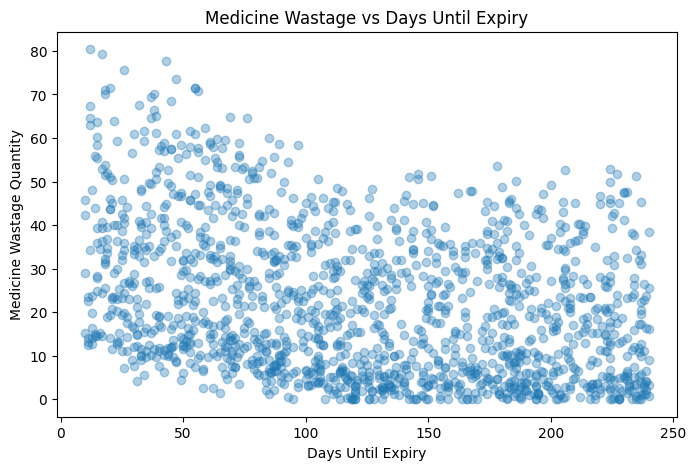

In [5]:
plt.figure(figsize=(8, 5))
plt.scatter(
df["days_to_expiry"],
df["wastage_quantity"],
alpha=0.35
)
plt.xlabel("Days Until Expiry")
plt.ylabel("Medicine Wastage Quantity")
plt.title("Medicine Wastage vs Days Until Expiry")
plt.show()

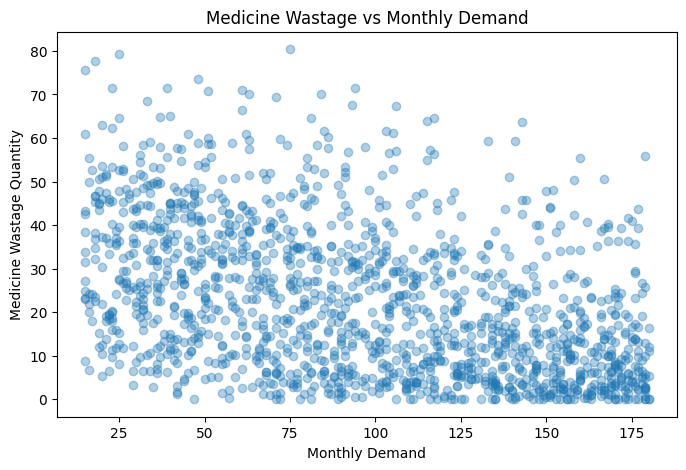

In [6]:
plt.figure(figsize=(8, 5))
plt.scatter(
df["monthly_demand"],
df["wastage_quantity"],
alpha=0.35
)
plt.xlabel("Monthly Demand")
plt.ylabel("Medicine Wastage Quantity")
plt.title("Medicine Wastage vs Monthly Demand")
plt.show()

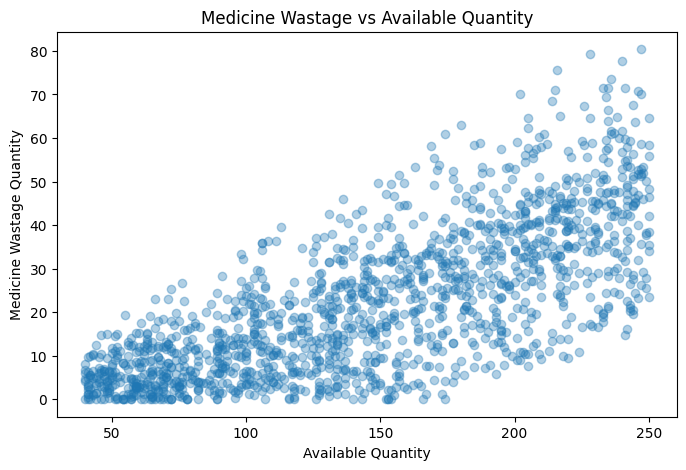

In [7]:
plt.figure(figsize=(8, 5))
plt.scatter(
df["quantity"],
df["wastage_quantity"],
alpha=0.35
)
plt.xlabel("Available Quantity")
plt.ylabel("Medicine Wastage Quantity")
plt.title("Medicine Wastage vs Available Quantity")
plt.show()

In [8]:
model = RandomForestRegressor(
n_estimators=200,
random_state=42,
min_samples_leaf=2
)
model.fit(X_train, y_train)
print("Model Training Completed!")
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

Model Training Completed!
MAE : 2.349608978511304
RMSE: 3.0729297107615987
R2  : 0.9682516738154328


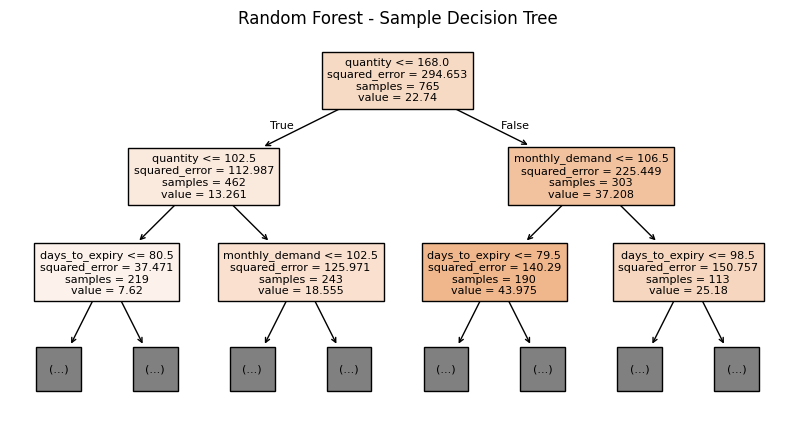

In [17]:
plt.figure(figsize=(10, 5))

plot_tree(
    model.estimators_[0],
    feature_names=X.columns,
    filled=True,
    max_depth=2,
    fontsize=8
)

plt.title("Random Forest - Sample Decision Tree")
plt.savefig("random_forest_medicine_tree.png", dpi=300, bbox_inches="tight")
plt.show()

In [12]:
sample = pd.DataFrame([{
    "quantity": 100,
    "monthly_demand": 40,
    "days_to_expiry": 30,
    "temperature": 28,
    "purchase_frequency": 2
}])

prediction = model.predict(sample)[0]

print("Predicted Wastage Quantity:",
      round(prediction, 2), "units")

if prediction >= 20:
    print("Wastage Risk: HIGH")
    print("Recommendation: Use or redistribute the medicine before expiry.")
elif prediction >= 10:
    print("Wastage Risk: MEDIUM")
    print("Recommendation: Monitor stock and demand closely.")
else:
    print("Wastage Risk: LOW")
    print("Recommendation: Normal inventory monitoring is sufficient.")

Predicted Wastage Quantity: 27.53 units
Wastage Risk: HIGH
Recommendation: Use or redistribute the medicine before expiry.
